# 第 9 章 · 因果注意力与二元词语言模型代码实验

本页把下一词预测拆成两件事：因果注意力只能看左侧上下文，二元词统计给出最简单的下一词分布。

[章节网页](../ch9.html)

## 运行内容

- 计算因果注意力
- 统计二元词频
- 绘制注意力热力图

## 0. 因果注意力

因果遮罩会遮住当前位置右侧的词。这里用可解释的查询/键特征观察注意力计算，再用二元词统计连接下一词预测。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.signal import correlate2d
from sklearn.datasets import load_breast_cancer, load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 加入因果遮罩后，每个位置只能看见自己和左侧词元。
lm_tokens = "the cat chased a mouse because it was hungry".split()
feature_names = ["article", "cat", "mouse", "action", "reason", "pronoun", "state"]
key_features = {
    "the": [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    "cat": [0.0, 2.1, 0.0, 0.0, 0.0, 0.0, 0.3],
    "chased": [0.0, 0.4, 0.3, 1.5, 0.0, 0.0, 0.0],
    "a": [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    "mouse": [0.0, 0.0, 2.1, 0.0, 0.0, 0.0, 0.0],
    "because": [0.0, 0.0, 0.0, 0.2, 1.7, 0.0, 0.0],
    "it": [0.0, 1.1, 0.8, 0.0, 0.0, 1.6, 0.0],
    "was": [0.0, 0.2, 0.0, 0.0, 0.3, 0.6, 1.2],
    "hungry": [0.0, 0.8, 0.0, 0.0, 0.7, 0.7, 1.4],
}
query_features = {
    "the": [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    "cat": [0.3, 1.7, 0.0, 0.0, 0.0, 0.0, 0.2],
    "chased": [0.0, 1.2, 1.0, 1.0, 0.0, 0.0, 0.0],
    "a": [1.0, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0],
    "mouse": [0.5, 0.0, 1.7, 0.7, 0.0, 0.0, 0.0],
    "because": [0.0, 0.5, 0.7, 0.9, 1.2, 0.0, 0.0],
    "it": [0.0, 1.4, 1.2, 0.1, 0.0, 1.0, 0.0],
    "was": [0.0, 0.6, 0.0, 0.0, 0.7, 1.1, 0.9],
    "hungry": [0.0, 1.4, 0.0, 0.0, 1.1, 1.0, 1.1],
}
K_lm = np.array([key_features[token] for token in lm_tokens], dtype=float)
Q_lm = np.array([query_features[token] for token in lm_tokens], dtype=float)
scores_lm = (Q_lm @ K_lm.T / math.sqrt(K_lm.shape[1])) / 0.45
scores_lm -= np.eye(len(lm_tokens)) * 1.35

# 这些加权模拟模型已经学到的短程依赖，便于在热力图里观察跨词关注。
semantic_boosts = {
    (2, 1): 2.4,  # chased -> cat
    (4, 3): 1.4,  # mouse -> a
    (4, 2): 1.2,  # mouse -> chased
    (5, 2): 2.0,  # because -> chased
    (5, 4): 1.7,  # because -> mouse
    (6, 1): 1.7,  # it -> cat
    (6, 4): 1.5,  # it -> mouse
    (7, 6): 2.2,  # was -> it
    (7, 5): 1.0,  # was -> because
    (8, 6): 1.8,  # hungry -> it
    (8, 7): 1.6,  # hungry -> was
    (8, 5): 1.0,  # hungry -> because
}
for (row, col), boost in semantic_boosts.items():
    scores_lm[row, col] += boost

mask = np.triu(np.ones_like(scores_lm), k=1).astype(bool)
scores_lm = np.where(mask, -1e9, scores_lm)
weights_lm = np.exp(scores_lm - scores_lm.max(axis=1, keepdims=True))
weights_lm = weights_lm / weights_lm.sum(axis=1, keepdims=True)

focus_lm_rows = []
for i, token in enumerate(lm_tokens):
    visible_ids = list(range(i + 1))
    sorted_ids = sorted(visible_ids, key=lambda j: weights_lm[i, j], reverse=True)[:3]
    focus_lm_rows.append({
        "位置": i,
        "当前词": token,
        "可见上下文": " ".join(lm_tokens[: i + 1]),
        "最强关注": f"{lm_tokens[sorted_ids[0]]}({weights_lm[i, sorted_ids[0]]:.2f})",
        "前三关注": " / ".join(f"{lm_tokens[j]}({weights_lm[i, j]:.2f})" for j in sorted_ids),
    })

display(pd.DataFrame(focus_lm_rows))
display(pd.DataFrame(np.round(weights_lm, 3), index=[f"{i}:{t}" for i, t in enumerate(lm_tokens)], columns=[f"{i}:{t}" for i, t in enumerate(lm_tokens)]))

,位置,当前词,可见上下文,最强关注,前三关注
0,0,the,the,the(1.00),the(1.00)
1,1,cat,the cat,cat(0.81),cat(0.81) / the(0.19)
2,2,chased,the cat chased,cat(0.97),cat(0.97) / chased(0.02) / the(0.01)
3,3,a,the cat chased a,the(0.47),the(0.47) / chased(0.21) / cat(0.20)
4,4,mouse,the cat chased a mouse,chased(0.47),chased(0.47) / a(0.24) / mouse(0.20)
5,5,because,the cat chased a mouse because,chased(0.57),chased(0.57) / mouse(0.33) / cat(0.04)
6,6,it,the cat chased a mouse because it,cat(0.56),cat(0.56) / mouse(0.32) / it(0.07)
7,7,was,the cat chased a mouse because it was,it(0.80),it(0.80) / because(0.09) / cat(0.04)
8,8,hungry,the cat chased a mouse because it was hungry,it(0.50),it(0.50) / was(0.25) / cat(0.09)


,0:the,1:cat,2:chased,3:a,4:mouse,5:because,6:it,7:was,8:hungry
0:the,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00
1:cat,0.190,0.810,0.000,0.000,0.000,0.000,0.000,0.000,0.00
2:chased,0.011,0.971,0.019,0.000,0.000,0.000,0.000,0.000,0.00
3:a,0.466,0.201,0.212,0.121,0.000,0.000,0.000,0.000,0.00
4:mouse,0.058,0.038,0.470,0.236,0.198,0.000,0.000,0.000,0.00
5:because,0.017,0.042,0.565,0.017,0.328,0.029,0.000,0.000,0.00
6:it,0.009,0.560,0.021,0.009,0.322,0.009,0.070,0.000,0.00
7:was,0.012,0.042,0.014,0.012,0.012,0.086,0.805,0.017,0.00
8:hungry,0.006,0.093,0.010,0.006,0.006,0.078,0.504,0.247,0.05


## 1. 下一词统计

二元词模型只根据当前词预测下一个词。它很简单，但能帮助读者理解语言模型的条件概率视角。

In [3]:
# 词二元统计：根据当前词统计下一个词分布。
text = "the cat chased the mouse because the cat was hungry and the mouse ran because the cat chased it".split()
bigram = defaultdict(Counter)
for a, b in zip(text, text[1:]):
    bigram[a][b] += 1

lm_rows = []
for token, counts in bigram.items():
    total = sum(counts.values())
    best_next, best_count = counts.most_common(1)[0]
    lm_rows.append({
        "当前词": token,
        "最可能下一个词": best_next,
        "概率": round(best_count / total, 3),
        "候选分布": dict(counts),
    })

display(pd.DataFrame(lm_rows))

,当前词,最可能下一个词,概率,候选分布
0,the,cat,0.600,"{'cat': 3, 'mouse': 2}"
1,cat,chased,0.667,"{'chased': 2, 'was': 1}"
2,chased,the,0.500,"{'the': 1, 'it': 1}"
3,mouse,because,0.500,"{'because': 1, 'ran': 1}"
4,because,the,1.000,{'the': 2}
5,was,hungry,1.000,{'hungry': 1}
6,hungry,and,1.000,{'and': 1}
7,and,the,1.000,{'the': 1}
8,ran,because,1.000,{'because': 1}


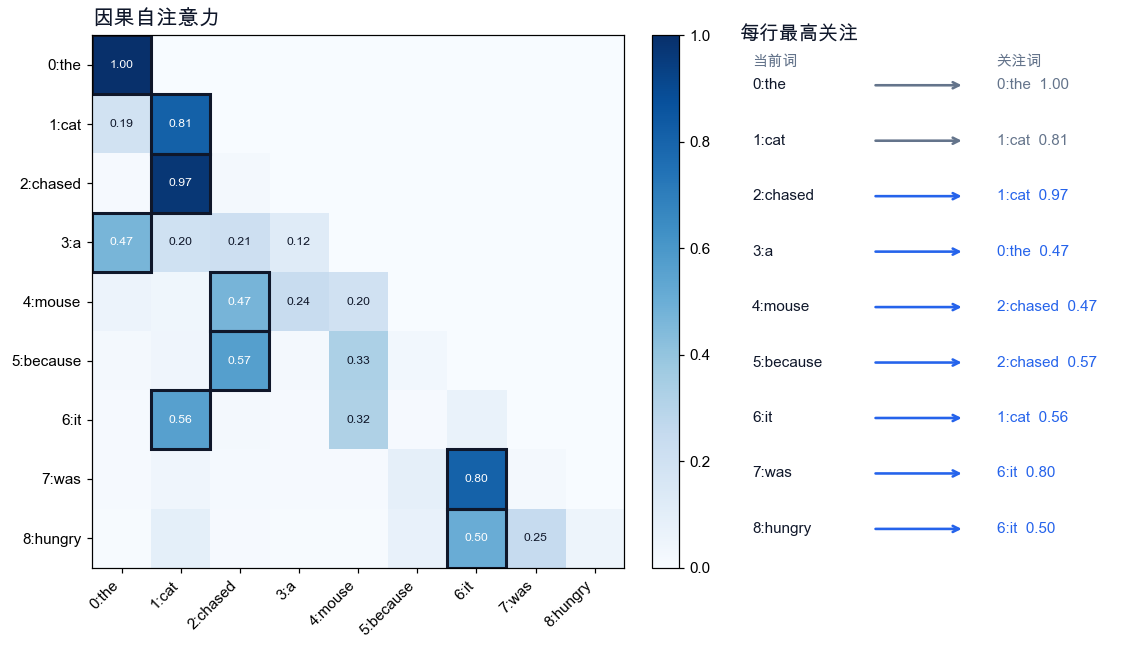

In [4]:
# 绘制因果注意力热力图，并单独列出每一行的最高关注。
fig, (ax, link_ax) = plt.subplots(
    1,
    2,
    figsize=(11.4, 6.0),
    gridspec_kw={"width_ratios": [1.35, 0.78]},
)
im = ax.imshow(weights_lm, cmap="Blues", vmin=0, vmax=weights_lm.max())
tick_labels = [f"{i}:{token}" for i, token in enumerate(lm_tokens)]
ax.set_xticks(range(len(lm_tokens)), tick_labels, rotation=45, ha="right")
ax.set_yticks(range(len(lm_tokens)), tick_labels)
for i in range(len(lm_tokens)):
    top_j = int(np.argmax(weights_lm[i]))
    for j in range(len(lm_tokens)):
        value = weights_lm[i, j]
        if value >= 0.10 or j == top_j:
            color = "#ffffff" if value > 0.38 else "#0f172a"
            weight = "bold" if j == top_j else "normal"
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=color, fontsize=8, fontweight=weight)
        if j == top_j:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="#0f172a", linewidth=2.0))
ax.set_title("因果自注意力", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

link_ax.set_xlim(0, 1)
link_ax.set_ylim(-0.7, len(lm_tokens) - 0.1)
link_ax.axis("off")
link_ax.text(0.02, len(lm_tokens) - 0.2, "每行最高关注", fontsize=13, fontweight="bold", color="#0f172a")
link_ax.text(0.05, len(lm_tokens) - 0.65, "当前词", color="#64748b", fontweight="bold")
link_ax.text(0.66, len(lm_tokens) - 0.65, "关注词", color="#64748b", fontweight="bold")
for i, token in enumerate(lm_tokens):
    y = len(lm_tokens) - 1 - i
    top_j = int(np.argmax(weights_lm[i]))
    top_token = lm_tokens[top_j]
    color = "#2563eb" if top_j != i else "#64748b"
    link_ax.text(0.05, y, f"{i}:{token}", va="center", color="#0f172a")
    link_ax.annotate(
        "",
        xy=(0.58, y),
        xytext=(0.35, y),
        arrowprops={"arrowstyle": "->", "lw": 1.7, "color": color},
    )
    link_ax.text(0.66, y, f"{top_j}:{top_token}  {weights_lm[i, top_j]:.2f}", va="center", color=color, fontweight="bold")
plt.tight_layout()
plt.show()